In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import scipy.io as sio

# ---------------------------------------------------------
# 0. visualization helper
# ---------------------------------------------------------
def show_gallery(vectors, shape=(46, 56), n_cols=10, max_images=20,
                  titles=None, title_colors=None, suptitle=None):
    """Display flattened image rows/columns as a grid of grayscale images."""
    num_images = min(len(vectors), max_images)
    n_cols = min(n_cols, num_images)
    n_rows = int(np.ceil(num_images / n_cols))

    fig, axs = plt.subplots(
        n_rows, n_cols, figsize=(2.4 * n_cols, 2.6 * n_rows), squeeze=False
    )
    for i in range(n_rows * n_cols):
        row, col = divmod(i, n_cols)
        ax = axs[row, col]
        if i < num_images:
            face = np.asarray(vectors[i]).reshape(shape)
            normalized = (face - face.min()) / (face.max() - face.min() + 1e-12)
            ax.imshow((normalized * 255).astype(np.uint8), cmap="gray")
            if titles is not None:
                color = title_colors[i] if title_colors is not None else "black"
                ax.set_title(titles[i], fontsize=9, color=color)
        ax.axis("off")

    if suptitle:
        fig.suptitle(suptitle, fontsize=14)
    plt.tight_layout()
    plt.show()

In [2]:
# ---------------------------------------------------------
# 1. PCA (eigenfaces)
# ---------------------------------------------------------
def pca(train_data, n_show=20, show=True):
    _, col = train_data.shape  # D, N
    average = train_data.mean(axis=1, keepdims=True)  # (D, 1)
    deviation = train_data - average  # (D, N)

    covariance = (1 / col) * (deviation.T @ deviation)  # (N, N)
    eigenvalue, small_eigenvector = np.linalg.eigh(covariance)
    index = eigenvalue.argsort()[::-1]
    eigenvalue = eigenvalue[index]
    small_eigenvector = small_eigenvector[:, index]  # (N, N)

    eigenvector = deviation @ small_eigenvector  # (D, N), unnormalized
    norm = np.linalg.norm(eigenvector, axis=0, keepdims=True)
    norm[norm == 0] = 1
    eigenvector = eigenvector / norm  # unit-norm eigenfaces

    if show:
        show_gallery(eigenvector.T, max_images=n_show, suptitle="Top eigenfaces (PCA)")

    return eigenvalue, eigenvector

In [3]:
# ---------------------------------------------------------
# 2. PCA + LDA (Fisherface)
# ---------------------------------------------------------
def compute_pca_lda_components(train_data, train_label):
    train_label = np.asarray(train_label).reshape(-1)
    group_cluster, count_item = np.unique(train_label, return_counts=True)
    num_cluster = group_cluster.size
    n_features = train_data.shape[1]

    _, eigenvector = pca(train_data.T, show=False)  # (D, N)

    scatter_b = np.zeros((n_features, n_features))
    scatter_w = np.zeros((n_features, n_features))
    total_mean = np.mean(train_data, axis=0)  # (D,)

    start_index = 0
    for cluster in range(num_cluster):
        num_item = count_item[cluster]
        cluster_data = train_data[start_index : start_index + num_item, :]
        cluster_mean = cluster_data.mean(axis=0)

        # between-class scatter
        deviation_b = cluster_mean - total_mean
        scatter_b += num_item * np.outer(deviation_b, deviation_b)

        # within-class scatter
        deviation_w = cluster_data - cluster_mean  # (num_item, D)
        scatter_w += deviation_w.T @ deviation_w

        start_index += num_item

    return {
        "eigenvector": eigenvector,
        "scatter_b": scatter_b,
        "scatter_w": scatter_w,
        "num_sample": train_data.shape[0],
        "num_cluster": num_cluster,
    }


def PCA_LDA(train_data, train_label, m_pca, m_lda, components=None, show=True):
    if components is None:
        components = compute_pca_lda_components(train_data, train_label)

    num_sample = components["num_sample"]
    num_cluster = components["num_cluster"]
    max_m_pca = num_sample - num_cluster
    max_m_lda = num_cluster - 1

    if m_pca > max_m_pca:
        print(f"wrong m_pca (must be <= {max_m_pca})")
        return None
    if m_lda > max_m_lda:
        print(f"wrong m_lda (must be <= {max_m_lda})")
        return None

    ### PCA step
    W_pca = components["eigenvector"][:, :m_pca].T  # (m_pca, D)

    ### LDA step
    matrix_1 = W_pca @ components["scatter_w"] @ W_pca.T  # (m_pca, m_pca), within
    matrix_2 = W_pca @ components["scatter_b"] @ W_pca.T  # (m_pca, m_pca), between

    if np.linalg.matrix_rank(matrix_1) < matrix_1.shape[0]:
        print("within-class scatter is singular. Try reducing m_pca.")
        return None

    lda_matrix = np.linalg.inv(matrix_1) @ matrix_2

    eigenvalue, eigenvector_lda = np.linalg.eig(lda_matrix)

    eigenvalue = np.real(eigenvalue)
    eigenvector_lda = np.real(eigenvector_lda)

    order = np.argsort(eigenvalue)[::-1]
    eigenvector_lda = eigenvector_lda[:, order]
    W_lda = eigenvector_lda[:, :m_lda].T  # (m_lda, m_pca)

    W_opt = W_lda @ W_pca  # (m_lda, D)

    if show:
        show_gallery(W_opt, max_images=min(20, m_lda), suptitle="Fisherfaces (W_opt)")

    return W_opt

In [4]:
def PCA_LDA_classify(train_data, test_data, train_label, test_label, m_pca, m_lda,
                      components=None, n_show=20, show=True):
    train_label = np.asarray(train_label).reshape(-1)
    test_label = np.asarray(test_label).reshape(-1)

    if show:
        print("CASE <m_pca : {}, m_lda : {}>".format(m_pca, m_lda))

    W_opt = PCA_LDA(train_data, train_label, m_pca, m_lda, components=components, show=show)
    if W_opt is None:
        return None

    train_data_PCA_LDA = train_data @ W_opt.T  # (N_train, m_lda)
    test_data_PCA_LDA = test_data @ W_opt.T  # (N_test, m_lda)

    kn = KNeighborsClassifier()
    kn = kn.fit(train_data_PCA_LDA, train_label)
    prediction = kn.predict(test_data_PCA_LDA)

    accuracy = kn.score(test_data_PCA_LDA, test_label)
    correct = prediction == test_label

    if show:
        sample_idx = np.random.choice(
            len(test_label), size=min(n_show, len(test_label)), replace=False
        )
        titles = [f"T:{test_label[i]} P:{prediction[i]}" for i in sample_idx]
        colors = ["green" if correct[i] else "red" for i in sample_idx]
        show_gallery(
            test_data[sample_idx],
            titles=titles,
            title_colors=colors,
            suptitle=f"Face recognition results (accuracy {accuracy * 100:.1f}%)",
        )
        print(f"accuracy : {accuracy * 100:.2f}%  ({correct.sum()}/{len(test_label)} correct)")

    return accuracy

In [5]:
# ---------------------------------------------------------
# 3. Grid search over (m_pca, m_lda)
# ---------------------------------------------------------
def PCA_LDA_grid_search(train_data, test_data, train_label, test_label, m_pca_list, m_lda_list):
    """Try every (m_pca, m_lda) combination in the given lists and report the one with the best test accuracy"""
    components = compute_pca_lda_components(train_data, train_label)

    results = []
    for m_pca in m_pca_list:
        for m_lda in m_lda_list:
            accuracy = PCA_LDA_classify(
                train_data, test_data, train_label, test_label,
                m_pca=m_pca, m_lda=m_lda,
                components=components, show=False,
            )
            if accuracy is not None:
                results.append((m_pca, m_lda, accuracy))

    if not results:
        print("No valid (m_pca, m_lda) combination in the given grid.")
        return None

    results.sort(key=lambda r: r[2], reverse=True)

    print(f"{'m_pca':>6} {'m_lda':>6} {'accuracy':>10}")
    for m_pca, m_lda, accuracy in results:
        print(f"{m_pca:>6} {m_lda:>6} {accuracy * 100:>9.2f}%")

    best_m_pca, best_m_lda, best_accuracy = results[0]
    print(f"\nBest combination: m_pca={best_m_pca}, m_lda={best_m_lda} (accuracy {best_accuracy * 100:.2f}%)")

    return best_m_pca, best_m_lda, best_accuracy

Train data shape: (416, 2576)
Train label shape: (416,)
Test data shape: (104, 2576)
Test label shape: (104,)
 m_pca  m_lda   accuracy
   200     51     87.50%
   100     30     86.54%
   150     40     86.54%
   350     51     86.54%
   150     30     85.58%
   150     51     83.65%
   200     30     83.65%
   200     40     83.65%
   300     51     83.65%
   100     40     82.69%
   250     51     82.69%
   100     51     79.81%
   250     30     78.85%
   250     40     77.88%
   300     30     77.88%
   300     40     77.88%
   350     40     77.88%
   350     30     72.12%
    50     30     71.15%
    50     40     65.38%
    50     51     50.96%

Best combination: m_pca=200, m_lda=51 (accuracy 87.50%)
CASE <m_pca : 200, m_lda : 51>


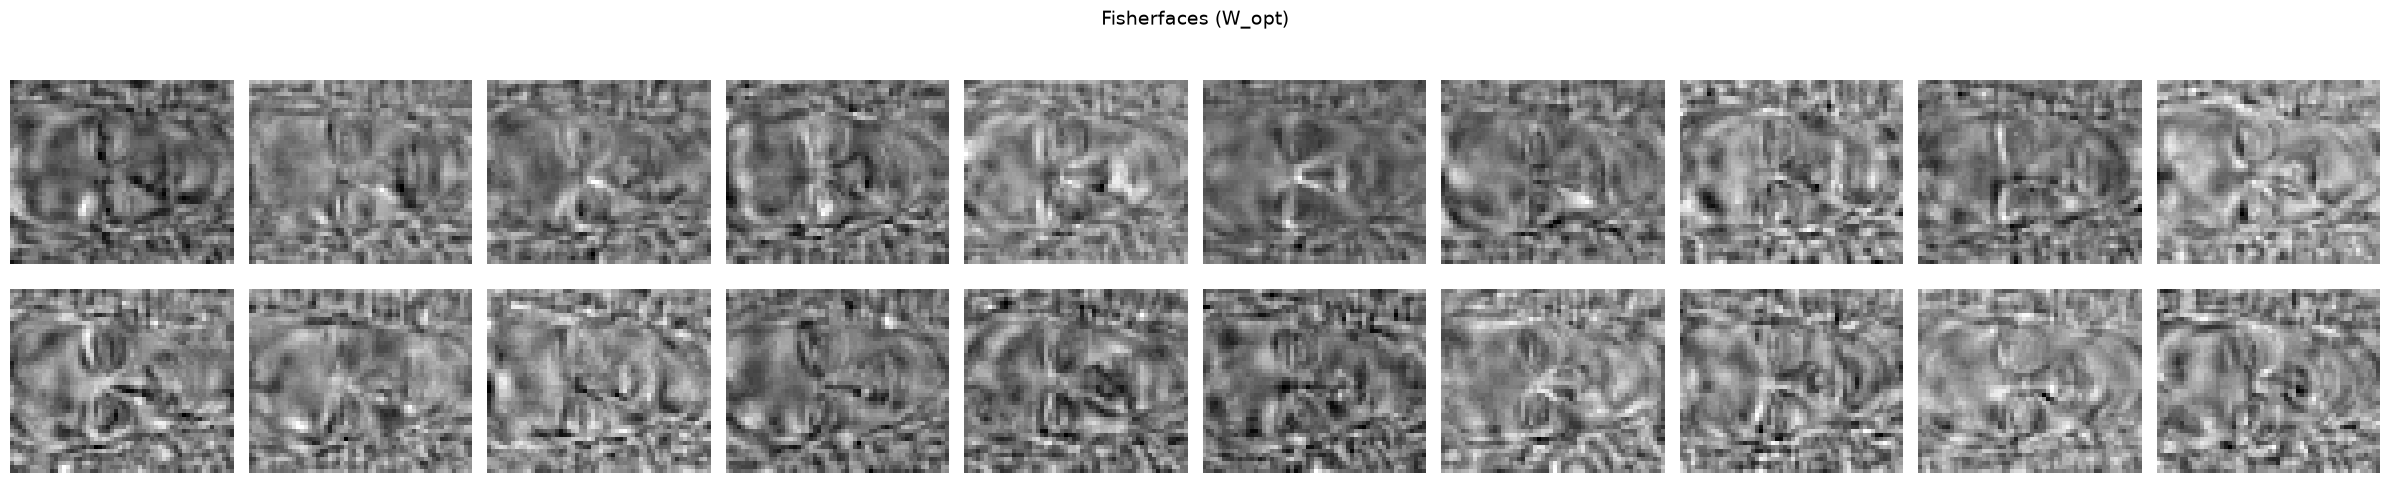

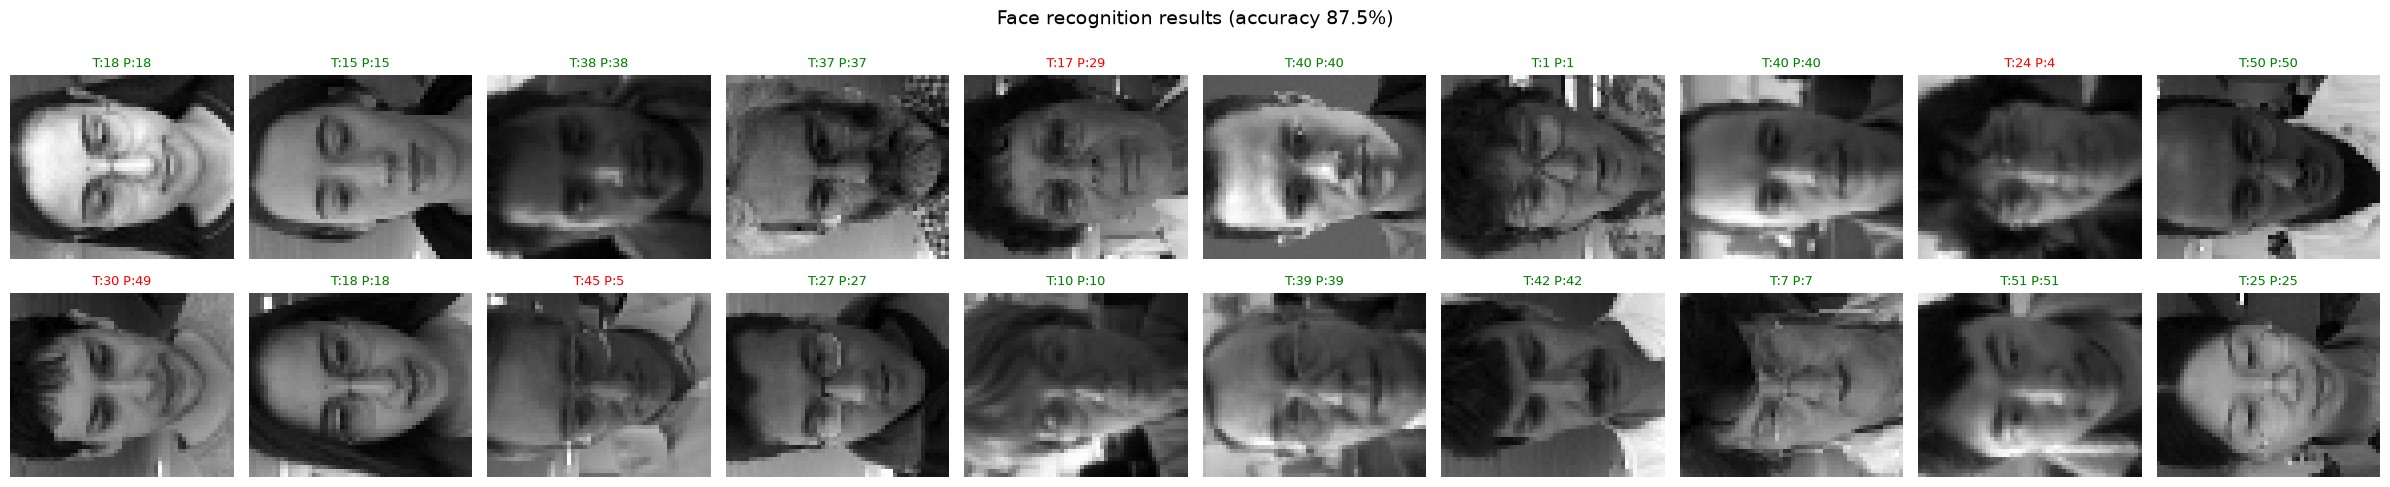

accuracy : 87.50%  (91/104 correct)


0.875

In [6]:
# load face image dataset
data = sio.loadmat("face.mat")
image = data["X"]  # (D, N)
label = data["l"].reshape(-1)  # (N,)

# train/test split (8:2 per class)
classes = np.unique(label)
train_images, test_images = [], []
train_labels, test_labels = [], []

for c in classes:
    idx = np.random.permutation(np.where(label == c)[0])
    n_train = int(0.8 * len(idx))
    train_images.append(image[:, idx[:n_train]].T)  # (n_train, D)
    test_images.append(image[:, idx[n_train:]].T)  # (n_test, D)
    train_labels.append(label[idx[:n_train]])
    test_labels.append(label[idx[n_train:]])

train_data = np.concatenate(train_images, axis=0)  # (N_train, D)
test_data = np.concatenate(test_images, axis=0)  # (N_test, D)
train_label = np.concatenate(train_labels)  # (N_train,)
test_label = np.concatenate(test_labels)  # (N_test,)

print("Train data shape:", train_data.shape)
print("Train label shape:", train_label.shape)
print("Test data shape:", test_data.shape)
print("Test label shape:", test_label.shape)

print("=" * 50)

# grid search over PCA/LDA dimensionality to find the best combination
m_pca_list = [50, 100, 150, 200, 250, 300, 350]
m_lda_list = [30, 40, 51]

best_m_pca, best_m_lda, best_accuracy = PCA_LDA_grid_search(
    train_data, test_data, train_label, test_label, m_pca_list, m_lda_list
)

print("=" * 50)

# re-run the best combination with the fisherface / result visualizations enabled
PCA_LDA_classify(train_data, test_data, train_label, test_label, m_pca=best_m_pca, m_lda=best_m_lda)
